# Jacobian unit-test figures — Test Case D

Figures for **Test Case D** of `tests/test_jacobian.py`
(`test_jacobian_general_angle_matches_rotation`, parametrized over
`alpha ∈ {0, 30, 45, 90, 137}°`).

**Idea.** For any grid-rotation angle the four returned components
must equal the analytic similarity transform `R . J_model . R^T`.
Case D sweeps angles and subsumes Cases A (0°) and B (90°).

Generated by JXP and Claude

In [1]:
# Imports at top (project convention). We import the test module itself so
# the figures are generated from the very same fixtures, parameters and
# assertions used by tests/test_jacobian.py.
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import dbof.utils.native_gradient as ng

# Make the repository's tests/ importable, then reuse its code.
_REPO = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
_TESTS = os.path.join(_REPO, 'tests')
if _TESTS not in sys.path:
    sys.path.insert(0, _TESTS)

import test_jacobian as tj  # noqa: E402

print('EDGE_MARGIN =', tj.EDGE_MARGIN, '| N_FACES =', tj.N_FACES)


EDGE_MARGIN = 3 | N_FACES = 13


## 1. Sweep the angles used by the parametrized test

For each angle we build the linear field, run the Jacobian, and
collect both the computed interior means and the analytic targets
from `tj.analytic_rotated_jacobian`.

In [2]:
d = 2500.0
a, b, e, f = 1.0e-5, 2.0e-5, -3.0e-5, 4.0e-5
angles_deg = [0.0, 30.0, 45.0, 90.0, 137.0]

computed = {k: [] for k in range(4)}   # interior means per component
analytic = {k: [] for k in range(4)}   # analytic targets per component
max_err = []                            # max interior abs error per angle

for deg in angles_deg:
    cs, sn = np.cos(np.radians(deg)), np.sin(np.radians(deg))
    ds, grid = tj.make_synthetic_grid(n=16, d=d, cs=cs, sn=sn)
    u_x, v_y = tj.add_linear_velocity(ds, d, a, b, e, f)
    outs = ng.calculate_jacobian(u_x, v_y, ds, grid)
    targs = tj.analytic_rotated_jacobian(a, b, e, f, cs=cs, sn=sn)
    err = 0.0
    for k, (o, t) in enumerate(zip(outs, targs)):
        computed[k].append(float(tj.interior(o).values.mean()))
        analytic[k].append(t)
        err = max(err, float(np.abs(tj.interior(o).values - t).max()))
    max_err.append(err)
    print(f'deg={deg:5.0f}  max interior abs err = {err:.2e}')


deg=    0  max interior abs err = 3.56e-20


deg=   30  max interior abs err = 6.10e-20


deg=   45  max interior abs err = 6.78e-20


deg=   90  max interior abs err = 5.76e-20


deg=  137  max interior abs err = 6.78e-20


## 2. Each component tracks `R J R^T` across angles

Solid curves are the analytic targets vs. angle; markers are the
computed interior means. They overlie exactly — the rotation
composition is correct for arbitrary angles.

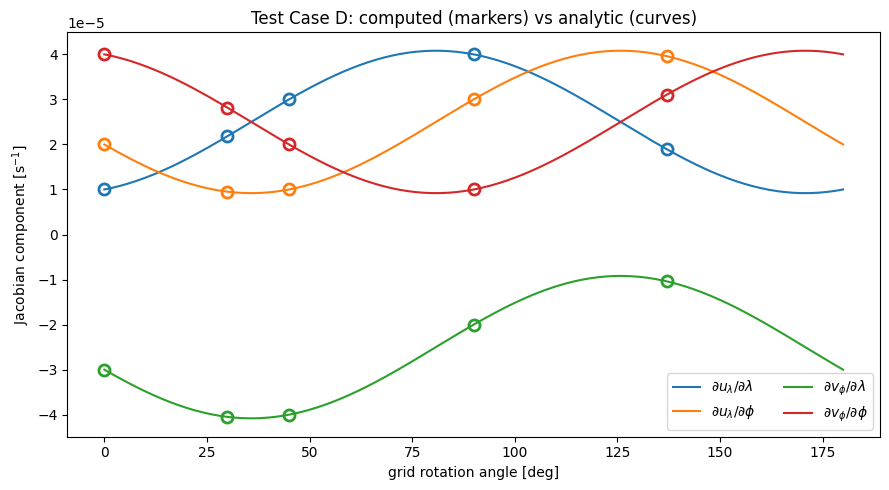

In [3]:
labels = [r'$\partial u_\lambda/\partial \lambda$',
          r'$\partial u_\lambda/\partial \phi$',
          r'$\partial v_\phi/\partial \lambda$',
          r'$\partial v_\phi/\partial \phi$']
fine = np.linspace(0, 180, 181)
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['C0', 'C1', 'C2', 'C3']
for k in range(4):
    cs_f, sn_f = np.cos(np.radians(fine)), np.sin(np.radians(fine))
    curve = [tj.analytic_rotated_jacobian(a, b, e, f, c_, s_)[k]
             for c_, s_ in zip(cs_f, sn_f)]
    ax.plot(fine, curve, '-', color=colors[k], label=labels[k])
    ax.plot(angles_deg, computed[k], 'o', color=colors[k], ms=8,
            mfc='none', mew=2)
ax.set_xlabel('grid rotation angle [deg]')
ax.set_ylabel('Jacobian component [s$^{-1}$]')
ax.set_title('Test Case D: computed (markers) vs analytic (curves)')
ax.legend(ncol=2); fig.tight_layout(); plt.show()


## 3. Error vs. angle stays at machine precision

The maximum interior absolute error at every swept angle is far
below the test tolerance (`rtol=1e-7`, values `~1e-5`).

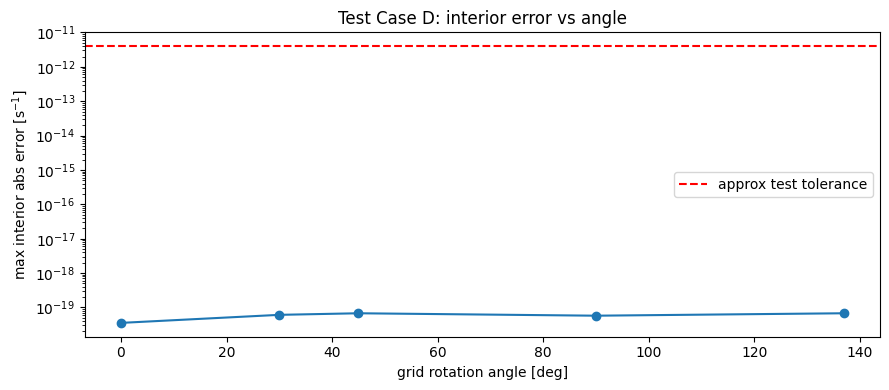

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(angles_deg, max_err, 'o-')
ax.axhline(1e-7 * max(abs(a), abs(b), abs(e), abs(f)), color='r', ls='--',
           label='approx test tolerance')
ax.set_xlabel('grid rotation angle [deg]')
ax.set_ylabel('max interior abs error [s$^{-1}$]')
ax.set_title('Test Case D: interior error vs angle')
ax.legend(); fig.tight_layout(); plt.show()


## 4. Run the actual (parametrized) unit test

Call the test once per swept angle; no exception means it passes.

In [5]:
for deg in angles_deg:
    tj.test_jacobian_general_angle_matches_rotation(deg)
print('Test Case D passed for all angles:', angles_deg)


Test Case D passed for all angles: [0.0, 30.0, 45.0, 90.0, 137.0]
